In [1]:
import sys
import pandas as pd

print("Python:", sys.executable)
print("Pandas:", pd.__version__)

Python: c:\Projects\PeakRisk\venv\Scripts\python.exe
Pandas: 3.0.5


In [2]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Location of Himalayan Database
DATA_PATH = (
    PROJECT_ROOT
    / "Data"
    / "raw"
    / "Himalayan Database"
    / "HIMDATA"
)

print("Database path:")
print(DATA_PATH)

Database path:
c:\Projects\PeakRisk\Data\raw\Himalayan Database\HIMDATA


In [3]:
print("Database files:")

for file in DATA_PATH.iterdir():
    print(file.name)

Database files:
exped.CDX
exped.DBF
exped.FPT
filters.CDX
filters.DBF
FILTERS.FPT
members.CDX
members.DBF
members.FPT
peaks.CDX
peaks.DBF
peaks.FPT
refer.CDX
refer.DBF
refer.FPT
SETUP.DBF


In [4]:

from dbfread import DBF

peaks_dbf = DBF(DATA_PATH / "peaks.DBF", load=True)

peaks = pd.DataFrame(iter(peaks_dbf))

print("Number of mountain records:", len(peaks))
print("Number of columns:", len(peaks.columns))

Number of mountain records: 503
Number of columns: 25


In [5]:
peaks.head()

,PEAKID,PKNAME,PKNAME2,LOCATION,HEIGHTM,HEIGHTF,HIMAL,REGION,OPEN,UNLISTED,...,PEAKMEMO,PYEAR,PSEASON,PEXPID,PSMTDATE,PCOUNTRY,PSUMMITERS,PSMTNOTE,REFERMEMO,PHOTOMEMO
0,AMAD,Ama Dablam,Amai Dablang,Khumbu Himal,6814,22356,12,2,True,False,...,"Other map altitudes:\r\n 6814m - HMG-MT, HMG...",1961,1,AMAD61101,Mar 13,"New Zealand, USA, UK","Mike Gill, Wally Romanes, Barry Bishop, Michae...",,NaN,W Face (High 126:5 May 1993)\r\nSE Face (High ...
1,AMPG,Amphu Gyabjen,Amphu Gyabien,Khumbu Himal (N of Ama Dablam),5630,18471,12,2,True,False,...,"Other map altitudes:\r\n 5630m - HMG-Finn, N...",1953,1,AMPG53101,Apr 11,UK,"John Hunt, Tom Bourdillon",,NaN,NaN
2,ANN1,Annapurna I,,Annapurna Himal,8091,26545,1,5,True,False,...,"Other map altitudes:\r\n 8091m - HMG-MT, HMG...",1950,1,ANN150101,Jun 03,France,"Maurice Herzog, Louis Lachenal",,Dyhrenfurth history 1950-1977 (MM 58:44-47 Nov...,S Face (High 122:3 Jan 1993) (Beghin accident)...
3,ANN2,Annapurna II,,Annapurna Himal,7937,26040,1,5,True,False,...,"Other map altitudes:\r\n 7937m - HMG-MT, HMG...",1960,1,ANN260101,May 17,"UK, Nepal","Richard Grant, Chris Bonington, Ang Nyima Sherpa",,Dyhrenfurth history 1960-1976 (MM 51:36-37 Sep...,N Face (MM 51:36 Sep 1976)
4,ANN3,Annapurna III,,Annapurna Himal,7555,24787,1,5,True,False,...,"Other map altitudes:\r\n 7555m - HMG-MT, HMG...",1961,1,ANN361101,May 06,India,"Mohan S. Kohli, Sonam Gyatso, Sonam Girmi",,NaN,S Side (MM 125:11 Jan 1989)\r\nSW Face (MM 71:...


In [6]:
peaks.columns.tolist()

['PEAKID',
 'PKNAME',
 'PKNAME2',
 'LOCATION',
 'HEIGHTM',
 'HEIGHTF',
 'HIMAL',
 'REGION',
 'OPEN',
 'UNLISTED',
 'TREKKING',
 'TREKYEAR',
 'RESTRICT',
 'PHOST',
 'PSTATUS',
 'PEAKMEMO',
 'PYEAR',
 'PSEASON',
 'PEXPID',
 'PSMTDATE',
 'PCOUNTRY',
 'PSUMMITERS',
 'PSMTNOTE',
 'REFERMEMO',
 'PHOTOMEMO']

In [7]:
peaks.columns.tolist()
peaks.isnull().sum()

PEAKID          0
PKNAME          0
PKNAME2         0
LOCATION        0
HEIGHTM         0
HEIGHTF         0
HIMAL           0
REGION          0
OPEN            0
UNLISTED        0
TREKKING        0
TREKYEAR        0
RESTRICT        0
PHOST           0
PSTATUS         0
PEAKMEMO        8
PYEAR           0
PSEASON         0
PEXPID          0
PSMTDATE        0
PCOUNTRY        0
PSUMMITERS      0
PSMTNOTE        0
REFERMEMO     484
PHOTOMEMO     425
dtype: int64

In [8]:
print("Rows:", peaks.shape[0])
print("Columns:", peaks.shape[1])

Rows: 503
Columns: 25


# Peak Data Dictionary

The `peaks` table contains information about mountains/peaks in the Himalayan Database.

We will investigate:
- Mountain identity and name
- Elevation
- Geographic region
- Whether the peak is open/closed
- Trekking and restriction information
- Historical first ascent information
- Summit information
- References and notes

In [9]:
peaks.dtypes

PEAKID          str
PKNAME          str
PKNAME2         str
LOCATION        str
HEIGHTM       int64
HEIGHTF       int64
HIMAL         int64
REGION        int64
OPEN           bool
UNLISTED       bool
TREKKING       bool
TREKYEAR        str
RESTRICT        str
PHOST         int64
PSTATUS       int64
PEAKMEMO        str
PYEAR           str
PSEASON       int64
PEXPID          str
PSMTDATE        str
PCOUNTRY        str
PSUMMITERS      str
PSMTNOTE        str
REFERMEMO       str
PHOTOMEMO       str
dtype: object

In [10]:
peaks.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PEAKID,503,503,AMAD,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PKNAME,503,503,Ama Dablam,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PKNAME2,503,257,,244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LOCATION,503,422,Ohmi Kangri Himal (WNW of Kangchenjunga),6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HEIGHTM,503.0,NaN,NaN,NaN,6633.912525,566.623177,5407.0,6225.5,6530.0,6874.5,8849.0
HEIGHTF,503.0,NaN,NaN,NaN,21764.817097,1859.00687,17740.0,20425.0,21424.0,22554.0,29032.0
HIMAL,503.0,NaN,NaN,NaN,10.417495,5.54811,1.0,6.0,11.0,15.0,20.0
REGION,503.0,NaN,NaN,NaN,3.827038,2.151601,1.0,2.0,4.0,6.0,7.0
OPEN,503,2,True,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UNLISTED,503,2,False,439,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
peaks[["PEAKID", "PKNAME", "HEIGHTM", "HEIGHTF"]].head(20)
peaks["HEIGHTM"].describe()

count     503.000000
mean     6633.912525
std       566.623177
min      5407.000000
25%      6225.500000
50%      6530.000000
75%      6874.500000
max      8849.000000
Name: HEIGHTM, dtype: float64

In [13]:
highest_peaks = (
    peaks[["PEAKID", "PKNAME", "HEIGHTM", "LOCATION"]]
    .sort_values("HEIGHTM", ascending=False)
    .head(20)
)

highest_peaks

,PEAKID,PKNAME,HEIGHTM,LOCATION
42,EVER,Everest,8849,Khumbu Himal
91,KANG,Kangchenjunga,8586,Kangchenjunga Himal
112,LHOT,Lhotse,8516,Khumbu Himal
187,YALU,Yalung Kang,8505,Kangchenjunga Himal (W summit of Kangchenjunga)
122,MAKA,Makalu,8485,Makalu Himal
92,KANS,Kangchenjunga South,8476,Kangchenjunga Himal
89,KANC,Kangchenjunga Central,8473,Kangchenjunga Himal (between Main and South su...
204,LHOM,Lhotse Middle,8410,Khumbu Himal (E of Lhotse)
117,LSHR,Lhotse Shar,8382,Khumbu Himal (ESE of Lhotse and Lhotse Middle)
20,CHOY,Cho Oyu,8188,Khumbu Himal (NW of Everest on Tibetan border)


In [14]:
peaks["HIMAL"].value_counts()
peaks["REGION"].value_counts()

REGION
2    137
7     91
5     74
1     74
6     49
4     42
3     36
Name: count, dtype: int64

In [15]:
# Load expedition data

exped_dbf = DBF(DATA_PATH / "exped.DBF", load=True)

exped = pd.DataFrame(iter(exped_dbf))

print("Expedition records:", len(exped))
print("Columns:", len(exped.columns))

Expedition records: 11854
Columns: 66


In [16]:
exped.head()

,EXPID,PEAKID,YEAR,SEASON,HOST,ROUTE1,ROUTE2,ROUTE3,ROUTE4,NATION,...,ACCIDENTS,ACHIEVMENT,AGENCY,COMRTE,STDRTE,PRIMRTE,PRIMMEM,PRIMREF,PRIMID,CHKSUM
0,ANN260101,ANN2,1960,1,1,NW Ridge-W Ridge,,,,UK,...,,,,None,None,False,False,None,,2442047
1,ANN269301,ANN2,1969,3,1,NW Ridge-W Ridge,,,,Yugoslavia,...,Draslar frostbitten hands and feet,,,None,None,False,False,None,,2445501
2,ANN273101,ANN2,1973,1,1,W Ridge-N Face,,,,Japan,...,,,,None,None,False,False,None,,2446797
3,ANN278301,ANN2,1978,3,1,N Face-W Ridge,,,,UK,...,,,,None,None,False,False,None,,2448822
4,ANN279301,ANN2,1979,3,1,N Face-W Ridge,NW Ridge of A-IV,,,UK,...,,,,None,None,False,False,None,,2449204


In [17]:
exped.columns.tolist()

['EXPID',
 'PEAKID',
 'YEAR',
 'SEASON',
 'HOST',
 'ROUTE1',
 'ROUTE2',
 'ROUTE3',
 'ROUTE4',
 'NATION',
 'LEADERS',
 'SPONSOR',
 'SUCCESS1',
 'SUCCESS2',
 'SUCCESS3',
 'SUCCESS4',
 'ASCENT1',
 'ASCENT2',
 'ASCENT3',
 'ASCENT4',
 'CLAIMED',
 'DISPUTED',
 'COUNTRIES',
 'APPROACH',
 'BCDATE',
 'SMTDATE',
 'SMTTIME',
 'SMTDAYS',
 'TOTDAYS',
 'TERMDATE',
 'TERMREASON',
 'TERMNOTE',
 'HIGHPOINT',
 'TRAVERSE',
 'SKI',
 'PARAPENTE',
 'CAMPS',
 'ROPE',
 'TOTMEMBERS',
 'SMTMEMBERS',
 'MDEATHS',
 'TOTHIRED',
 'SMTHIRED',
 'HDEATHS',
 'NOHIRED',
 'O2USED',
 'O2NONE',
 'O2CLIMB',
 'O2DESCENT',
 'O2SLEEP',
 'O2MEDICAL',
 'O2TAKEN',
 'O2UNKWN',
 'OTHERSMTS',
 'CAMPSITES',
 'ROUTEMEMO',
 'ACCIDENTS',
 'ACHIEVMENT',
 'AGENCY',
 'COMRTE',
 'STDRTE',
 'PRIMRTE',
 'PRIMMEM',
 'PRIMREF',
 'PRIMID',
 'CHKSUM']

In [18]:
exped.info()

<class 'pandas.DataFrame'>
RangeIndex: 11854 entries, 0 to 11853
Data columns (total 66 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   EXPID       11854 non-null  str   
 1   PEAKID      11854 non-null  str   
 2   YEAR        11854 non-null  str   
 3   SEASON      11854 non-null  int64 
 4   HOST        11854 non-null  int64 
 5   ROUTE1      11854 non-null  str   
 6   ROUTE2      11854 non-null  str   
 7   ROUTE3      11854 non-null  str   
 8   ROUTE4      11854 non-null  str   
 9   NATION      11854 non-null  str   
 10  LEADERS     11854 non-null  str   
 11  SPONSOR     11854 non-null  str   
 12  SUCCESS1    11854 non-null  bool  
 13  SUCCESS2    11854 non-null  bool  
 14  SUCCESS3    11854 non-null  bool  
 15  SUCCESS4    11854 non-null  bool  
 16  ASCENT1     11854 non-null  str   
 17  ASCENT2     11854 non-null  str   
 18  ASCENT3     11854 non-null  str   
 19  ASCENT4     11854 non-null  str   
 20  CLAIMED     11854

In [19]:
exped.isnull().sum()

EXPID         0
PEAKID        0
YEAR          0
SEASON        0
HOST          0
           ... 
PRIMRTE       0
PRIMMEM       0
PRIMREF    3723
PRIMID        0
CHKSUM        0
Length: 66, dtype: int64

In [20]:
for i, col in enumerate(exped.columns, start=1):
    print(f"{i:02d}. {col}")

01. EXPID
02. PEAKID
03. YEAR
04. SEASON
05. HOST
06. ROUTE1
07. ROUTE2
08. ROUTE3
09. ROUTE4
10. NATION
11. LEADERS
12. SPONSOR
13. SUCCESS1
14. SUCCESS2
15. SUCCESS3
16. SUCCESS4
17. ASCENT1
18. ASCENT2
19. ASCENT3
20. ASCENT4
21. CLAIMED
22. DISPUTED
23. COUNTRIES
24. APPROACH
25. BCDATE
26. SMTDATE
27. SMTTIME
28. SMTDAYS
29. TOTDAYS
30. TERMDATE
31. TERMREASON
32. TERMNOTE
33. HIGHPOINT
34. TRAVERSE
35. SKI
36. PARAPENTE
37. CAMPS
38. ROPE
39. TOTMEMBERS
40. SMTMEMBERS
41. MDEATHS
42. TOTHIRED
43. SMTHIRED
44. HDEATHS
45. NOHIRED
46. O2USED
47. O2NONE
48. O2CLIMB
49. O2DESCENT
50. O2SLEEP
51. O2MEDICAL
52. O2TAKEN
53. O2UNKWN
54. OTHERSMTS
55. CAMPSITES
56. ROUTEMEMO
57. ACCIDENTS
58. ACHIEVMENT
59. AGENCY
60. COMRTE
61. STDRTE
62. PRIMRTE
63. PRIMMEM
64. PRIMREF
65. PRIMID
66. CHKSUM


In [22]:
exped.head(3).T

,0,1,2
EXPID,ANN260101,ANN269301,ANN273101
PEAKID,ANN2,ANN2,ANN2
YEAR,1960,1969,1973
SEASON,1,3,1
HOST,1,1,1
...,...,...,...
PRIMRTE,False,False,False
PRIMMEM,False,False,False
PRIMREF,None,None,None
PRIMID,,,


In [23]:
[column for column in exped.columns if any(
    word in column.upper()
    for word in ["SUMMIT", "DEATH", "MEMBER", "SUCCESS", "ROUTE", "CAMP", "OXY", "SHERPA"]
)]

['ROUTE1',
 'ROUTE2',
 'ROUTE3',
 'ROUTE4',
 'SUCCESS1',
 'SUCCESS2',
 'SUCCESS3',
 'SUCCESS4',
 'CAMPS',
 'TOTMEMBERS',
 'SMTMEMBERS',
 'MDEATHS',
 'HDEATHS',
 'CAMPSITES',
 'ROUTEMEMO']

In [24]:
print("Total expeditions:", len(exped))
print("Unique expedition IDs:", exped["EXPID"].nunique())
print("Unique peaks:", exped["PEAKID"].nunique())
print("Years:", exped["YEAR"].min(), "to", exped["YEAR"].max())

Total expeditions: 11854
Unique expedition IDs: 11849
Unique peaks: 439
Years: 1905 to 2025


In [25]:
for i, col in enumerate(exped.columns, start=1):
    print(f"{i:02d}. {col}")
    exped.head(3).T
    [column for column in exped.columns if any(
    word in column.upper()
    for word in ["SUMMIT", "DEATH", "MEMBER", "SUCCESS", "ROUTE", "CAMP", "OXY", "SHERPA"]
)]

01. EXPID
02. PEAKID
03. YEAR
04. SEASON
05. HOST
06. ROUTE1
07. ROUTE2
08. ROUTE3
09. ROUTE4
10. NATION
11. LEADERS
12. SPONSOR
13. SUCCESS1
14. SUCCESS2
15. SUCCESS3
16. SUCCESS4
17. ASCENT1
18. ASCENT2
19. ASCENT3
20. ASCENT4
21. CLAIMED
22. DISPUTED
23. COUNTRIES
24. APPROACH
25. BCDATE
26. SMTDATE
27. SMTTIME
28. SMTDAYS
29. TOTDAYS
30. TERMDATE
31. TERMREASON
32. TERMNOTE
33. HIGHPOINT
34. TRAVERSE
35. SKI
36. PARAPENTE
37. CAMPS
38. ROPE
39. TOTMEMBERS
40. SMTMEMBERS
41. MDEATHS
42. TOTHIRED
43. SMTHIRED
44. HDEATHS
45. NOHIRED
46. O2USED
47. O2NONE
48. O2CLIMB
49. O2DESCENT
50. O2SLEEP
51. O2MEDICAL
52. O2TAKEN
53. O2UNKWN
54. OTHERSMTS
55. CAMPSITES
56. ROUTEMEMO
57. ACCIDENTS
58. ACHIEVMENT
59. AGENCY
60. COMRTE
61. STDRTE
62. PRIMRTE
63. PRIMMEM
64. PRIMREF
65. PRIMID
66. CHKSUM


In [26]:
for i, col in enumerate(exped.columns[24:62], start=25):
    print(f"{i:02d}. {col}")

25. BCDATE
26. SMTDATE
27. SMTTIME
28. SMTDAYS
29. TOTDAYS
30. TERMDATE
31. TERMREASON
32. TERMNOTE
33. HIGHPOINT
34. TRAVERSE
35. SKI
36. PARAPENTE
37. CAMPS
38. ROPE
39. TOTMEMBERS
40. SMTMEMBERS
41. MDEATHS
42. TOTHIRED
43. SMTHIRED
44. HDEATHS
45. NOHIRED
46. O2USED
47. O2NONE
48. O2CLIMB
49. O2DESCENT
50. O2SLEEP
51. O2MEDICAL
52. O2TAKEN
53. O2UNKWN
54. OTHERSMTS
55. CAMPSITES
56. ROUTEMEMO
57. ACCIDENTS
58. ACHIEVMENT
59. AGENCY
60. COMRTE
61. STDRTE
62. PRIMRTE


In [27]:
pd.set_option("display.max_columns", None)

exped.head(2)

,EXPID,PEAKID,YEAR,SEASON,HOST,ROUTE1,ROUTE2,ROUTE3,ROUTE4,NATION,LEADERS,SPONSOR,SUCCESS1,SUCCESS2,SUCCESS3,SUCCESS4,ASCENT1,ASCENT2,ASCENT3,ASCENT4,CLAIMED,DISPUTED,COUNTRIES,APPROACH,BCDATE,SMTDATE,SMTTIME,SMTDAYS,TOTDAYS,TERMDATE,TERMREASON,TERMNOTE,HIGHPOINT,TRAVERSE,SKI,PARAPENTE,CAMPS,ROPE,TOTMEMBERS,SMTMEMBERS,MDEATHS,TOTHIRED,SMTHIRED,HDEATHS,NOHIRED,O2USED,O2NONE,O2CLIMB,O2DESCENT,O2SLEEP,O2MEDICAL,O2TAKEN,O2UNKWN,OTHERSMTS,CAMPSITES,ROUTEMEMO,ACCIDENTS,ACHIEVMENT,AGENCY,COMRTE,STDRTE,PRIMRTE,PRIMMEM,PRIMREF,PRIMID,CHKSUM
0,ANN260101,ANN2,1960,1,1,NW Ridge-W Ridge,,,,UK,J. O. M. Roberts,,True,False,False,False,1st,,,,False,False,"India, Nepal",Marshyangdi->Hongde->Sabje Khola,1960-03-15,1960-05-17,1530,63,0,None,1,,7937,False,False,False,6,0,10,2,0,9,1,0,False,True,False,True,False,True,False,False,False,Climbed Annapurna IV (ANN4-601-01),"BC(15/03,3350m),ABC(4575m),C1(5365m),C2(5800m)...",NaN,,,,None,None,False,False,None,,2442047
1,ANN269301,ANN2,1969,3,1,NW Ridge-W Ridge,,,,Yugoslavia,Ales Kunaver,Mountaineering Club of Slovenia,True,False,False,False,2nd,,,,False,False,,Marshyangdi->Hongde->Sabje Khola,1969-09-25,1969-10-22,1800,27,31,1969-10-26,1,,7937,False,False,False,6,0,10,2,0,0,0,0,False,False,True,False,False,False,False,False,False,Climbed Annapurna IV (ANN4-693-02),"LowBC(25/09,3950m),BC(27/09,4650m),C1(27/09,53...","Summited after sunset, returned to C6 at 2:30 ...",Draslar frostbitten hands and feet,,,None,None,False,False,None,,2445501


In [28]:
keywords = [
    "SUMMIT", "DEATH", "MEMBER", "SUCCESS",
    "ROUTE", "CAMP", "OXY", "SHERPA",
    "ASCENT", "DISPUTED", "CLAIMED"
]

for col in exped.columns:
    if any(word in col.upper() for word in keywords):
        print(col)

ROUTE1
ROUTE2
ROUTE3
ROUTE4
SUCCESS1
SUCCESS2
SUCCESS3
SUCCESS4
ASCENT1
ASCENT2
ASCENT3
ASCENT4
CLAIMED
DISPUTED
CAMPS
TOTMEMBERS
SMTMEMBERS
MDEATHS
HDEATHS
CAMPSITES
ROUTEMEMO


In [30]:
members_dbf = DBF(DATA_PATH / "members.DBF", load=True)

members = pd.DataFrame(iter(members_dbf))

print("Member records:", len(members))
print("Number of columns:", len(members.columns))

Member records: 94999
Number of columns: 78


In [31]:
for i, col in enumerate(members.columns, start=1):
    print(f"{i:02d}. {col}")

01. EXPID
02. MEMBID
03. PEAKID
04. MYEAR
05. MSEASON
06. FNAME
07. LNAME
08. SEX
09. AGE
10. BIRTHDATE
11. YOB
12. CALCAGE
13. CITIZEN
14. STATUS
15. RESIDENCE
16. OCCUPATION
17. LEADER
18. DEPUTY
19. BCONLY
20. NOTTOBC
21. SUPPORT
22. DISABLED
23. HIRED
24. SHERPA
25. TIBETAN
26. MSUCCESS
27. MCLAIMED
28. MDISPUTED
29. MSOLO
30. MTRAVERSE
31. MSKI
32. MPARAPENTE
33. MSPEED
34. MHIGHPT
35. MPERHIGHPT
36. MSMTDATE1
37. MSMTDATE2
38. MSMTDATE3
39. MSMTTIME1
40. MSMTTIME2
41. MSMTTIME3
42. MROUTE1
43. MROUTE2
44. MROUTE3
45. MASCENT1
46. MASCENT2
47. MASCENT3
48. MO2USED
49. MO2NONE
50. MO2CLIMB
51. MO2DESCENT
52. MO2SLEEP
53. MO2MEDICAL
54. MO2NOTE
55. DEATH
56. DEATHDATE
57. DEATHTIME
58. DEATHTYPE
59. DEATHHGTM
60. DEATHCLASS
61. AMS
62. WEATHER
63. INJURY
64. INJURYDATE
65. INJURYTIME
66. INJURYTYPE
67. INJURYHGTM
68. DEATHNOTE
69. MEMBERMEMO
70. NECROLOGY
71. MSMTBID
72. MSMTTERM
73. HCN
74. MCHKSUM
75. MSMTNOTE1
76. MSMTNOTE2
77. MSMTNOTE3
78. DEATHRTE


In [32]:
keywords = [
    "SUCCESS",
    "DEATH",
    "SUMMIT",
    "DATE",
    "TIME",
    "HEIGHT",
    "WEATHER",
    "INJURY"
]

for col in members.columns:
    if any(word in col.upper() for word in keywords):
        print(col)

BIRTHDATE
MSUCCESS
MSMTDATE1
MSMTDATE2
MSMTDATE3
MSMTTIME1
MSMTTIME2
MSMTTIME3
DEATH
DEATHDATE
DEATHTIME
DEATHTYPE
DEATHHGTM
DEATHCLASS
WEATHER
INJURY
INJURYDATE
INJURYTIME
INJURYTYPE
INJURYHGTM
DEATHNOTE
DEATHRTE


In [33]:
members.head(3).T

,0,1,2
EXPID,AMAD78301,AMAD78301,AMAD78301
MEMBID,01,02,03
PEAKID,AMAD,AMAD,AMAD
MYEAR,1978,1978,1978
MSEASON,3,3,3
...,...,...,...
MCHKSUM,2426937,2426501,2431569
MSMTNOTE1,NaN,NaN,NaN
MSMTNOTE2,NaN,NaN,NaN
MSMTNOTE3,NaN,NaN,NaN


In [3]:
import pandas as pd
from dbfread import DBF

In [4]:
members_dbf = DBF(DATA_PATH / "members.DBF", load=True)

members = pd.DataFrame(iter(members_dbf))

print("Member records:", len(members))
print("Number of columns:", len(members.columns))

NameError: name 'DATA_PATH' is not defined

In [5]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "Data"
    / "raw"
    / "Himalayan Database"
    / "HIMDATA"
)

print(DATA_PATH)

c:\Projects\PeakRisk\Data\raw\Himalayan Database\HIMDATA


In [6]:
import pandas as pd
from dbfread import DBF

In [7]:
members_dbf = DBF(DATA_PATH / "members.DBF", load=True)

members = pd.DataFrame(iter(members_dbf))

print("Member records:", len(members))
print("Number of columns:", len(members.columns))

Member records: 94999
Number of columns: 78


In [8]:
for i, col in enumerate(members.columns, start=1):
    print(f"{i:02d}. {col}")

01. EXPID
02. MEMBID
03. PEAKID
04. MYEAR
05. MSEASON
06. FNAME
07. LNAME
08. SEX
09. AGE
10. BIRTHDATE
11. YOB
12. CALCAGE
13. CITIZEN
14. STATUS
15. RESIDENCE
16. OCCUPATION
17. LEADER
18. DEPUTY
19. BCONLY
20. NOTTOBC
21. SUPPORT
22. DISABLED
23. HIRED
24. SHERPA
25. TIBETAN
26. MSUCCESS
27. MCLAIMED
28. MDISPUTED
29. MSOLO
30. MTRAVERSE
31. MSKI
32. MPARAPENTE
33. MSPEED
34. MHIGHPT
35. MPERHIGHPT
36. MSMTDATE1
37. MSMTDATE2
38. MSMTDATE3
39. MSMTTIME1
40. MSMTTIME2
41. MSMTTIME3
42. MROUTE1
43. MROUTE2
44. MROUTE3
45. MASCENT1
46. MASCENT2
47. MASCENT3
48. MO2USED
49. MO2NONE
50. MO2CLIMB
51. MO2DESCENT
52. MO2SLEEP
53. MO2MEDICAL
54. MO2NOTE
55. DEATH
56. DEATHDATE
57. DEATHTIME
58. DEATHTYPE
59. DEATHHGTM
60. DEATHCLASS
61. AMS
62. WEATHER
63. INJURY
64. INJURYDATE
65. INJURYTIME
66. INJURYTYPE
67. INJURYHGTM
68. DEATHNOTE
69. MEMBERMEMO
70. NECROLOGY
71. MSMTBID
72. MSMTTERM
73. HCN
74. MCHKSUM
75. MSMTNOTE1
76. MSMTNOTE2
77. MSMTNOTE3
78. DEATHRTE


In [9]:
keywords = [
    "SUCCESS",
    "DEATH",
    "SUMMIT",
    "DATE",
    "TIME",
    "HEIGHT",
    "WEATHER",
    "INJURY"
]

for col in members.columns:
    if any(word in col.upper() for word in keywords):
        print(col)

BIRTHDATE
MSUCCESS
MSMTDATE1
MSMTDATE2
MSMTDATE3
MSMTTIME1
MSMTTIME2
MSMTTIME3
DEATH
DEATHDATE
DEATHTIME
DEATHTYPE
DEATHHGTM
DEATHCLASS
WEATHER
INJURY
INJURYDATE
INJURYTIME
INJURYTYPE
INJURYHGTM
DEATHNOTE
DEATHRTE


In [10]:
print("MSUCCESS values:")
print(members["MSUCCESS"].value_counts(dropna=False))

print("\nDEATH values:")
print(members["DEATH"].value_counts(dropna=False))

print("\nDEATHTYPE values:")
print(members["DEATHTYPE"].value_counts(dropna=False))

print("\nDEATHCLASS values:")
print(members["DEATHCLASS"].value_counts(dropna=False))

MSUCCESS values:
MSUCCESS
False    53948
True     41051
Name: count, dtype: int64

DEATH values:
DEATH
False    93812
True      1187
Name: count, dtype: int64

DEATHTYPE values:
DEATHTYPE
0     93812
7       383
4       346
1       123
10       69
9        54
2        52
3        42
8        31
11       30
5        26
6        20
12       11
Name: count, dtype: int64

DEATHCLASS values:
DEATHCLASS
0    93812
3      491
5      351
4      129
2       94
1       73
6       45
7        4
Name: count, dtype: int64


In [11]:
members[
    [
        "EXPID",
        "PEAKID",
        "MSUCCESS",
        "MSMTDATE1",
        "MHIGHPT",
        "DEATH",
        "DEATHDATE",
        "DEATHTYPE",
        "DEATHHGTM",
        "DEATHCLASS",
        "WEATHER",
        "INJURY"
    ]
].head(20)

,EXPID,PEAKID,MSUCCESS,MSMTDATE1,MHIGHPT,DEATH,DEATHDATE,DEATHTYPE,DEATHHGTM,DEATHCLASS,WEATHER,INJURY
0,AMAD78301,AMAD,False,None,False,False,None,0,0,0,False,False
1,AMAD78301,AMAD,False,1978-10-21,True,False,None,0,0,0,False,False
2,AMAD78301,AMAD,False,None,False,False,None,0,0,0,False,False
3,AMAD78301,AMAD,False,1978-10-21,True,False,None,0,0,0,False,False
4,AMAD78301,AMAD,False,None,False,False,None,0,0,0,False,False
5,AMAD78301,AMAD,False,1978-10-20,True,False,None,0,0,0,False,False
6,AMAD78301,AMAD,False,1978-10-20,True,False,None,0,0,0,False,False
7,AMAD78301,AMAD,False,1978-10-21,True,False,None,0,0,0,False,False
8,AMAD79101,AMAD,False,None,False,False,None,0,0,0,False,False
9,AMAD79101,AMAD,True,1979-04-22,True,False,None,0,0,0,False,False


In [13]:
# Load peaks table
peaks_dbf = DBF(DATA_PATH / "peaks.DBF", load=True)
peaks = pd.DataFrame(iter(peaks_dbf))

# Load expeditions table
exped_dbf = DBF(DATA_PATH / "exped.DBF", load=True)
exped = pd.DataFrame(iter(exped_dbf))

print("Peaks:", len(peaks))
print("Expeditions:", len(exped))
print("Members:", len(members))

Peaks: 503
Expeditions: 11854
Members: 94999


In [14]:
print("Unique PEAKID values")
print("Peaks:", peaks["PEAKID"].nunique())
print("Expeditions:", exped["PEAKID"].nunique())
print("Members:", members["PEAKID"].nunique())

print("\nUnique EXPID values")
print("Expeditions:", exped["EXPID"].nunique())
print("Members:", members["EXPID"].nunique())

Unique PEAKID values
Peaks: 503
Expeditions: 439
Members: 439

Unique EXPID values
Expeditions: 11849
Members: 11834


In [15]:
print("Unique PEAKID values")
print("Peaks:", peaks["PEAKID"].nunique())
print("Expeditions:", exped["PEAKID"].nunique())
print("Members:", members["PEAKID"].nunique())

print("\nUnique EXPID values")
print("Expeditions:", exped["EXPID"].nunique())
print("Members:", members["EXPID"].nunique())

Unique PEAKID values
Peaks: 503
Expeditions: 439
Members: 439

Unique EXPID values
Expeditions: 11849
Members: 11834


In [16]:
missing_expid = set(exped["EXPID"]) - set(members["EXPID"])

print("Expedition IDs missing from members:", len(missing_expid))
print(sorted(missing_expid))

Expedition IDs missing from members: 15
['CHEO87301', 'DHA149001', 'EVER19185', 'EVER23150', 'EVER65102', 'EVER68101', 'EVER79102', 'GAUR73301', 'KGUR65101', 'MAKA34101', 'MANA70301', 'MARD67001', 'URKM71102', 'YALU65101', 'YALU67101']


In [17]:
missing_from_exped = set(members["EXPID"]) - set(exped["EXPID"])

print("Member EXPIDs missing from expeditions:", len(missing_from_exped))
print(sorted(missing_from_exped))

Member EXPIDs missing from expeditions: 0
[]


In [18]:
peaks_without_expeditions = peaks[
    ~peaks["PEAKID"].isin(exped["PEAKID"])
]

print("Peaks without expedition records:", len(peaks_without_expeditions))

peaks_without_expeditions[
    ["PEAKID", "PKNAME", "HEIGHTM", "REGION", "LOCATION"]
].head(20)

Peaks without expedition records: 64


,PEAKID,PKNAME,HEIGHTM,REGION,LOCATION
10,APIW,Api West,7076,7,Api Himal (W of Api)
95,NAYA,Naya Kanga,5863,3,Jugal Himal (W of Ganchempo by Kangja La)
98,KHON,Khongma Tse,5798,2,Khumbu Himal (SW of Nuptse)
227,KGRW,Khangri West,6658,2,Khumbu Himal (W of Pumori)
249,CHAB,Chabuk,6792,1,Ohmi Kangri Himal (E of Ohmi Kangri on Tibetan...
259,NAG2,Nangpai Gosum II,7287,2,Khumbu Himal (WSW of Cho Oyu on Tibetan border)
283,LNGK,Langchung Khang,6786,1,Jongsang Himal (NW of Langpo on Indian border)
285,NAM2,Nampa II,6585,7,Api Himal (W of Nampa)
286,NAM3,Nampa III,6611,7,Api Himal (SE of Nampa)
287,NAMS,Nampa South,6130,7,"Api Himal (S of Nampa, W of Nampa Chuli)"


In [19]:
print("Total peaks:", len(peaks))
print("Peaks with expeditions:", exped["PEAKID"].nunique())
print("Peaks without expeditions:", len(peaks_without_expeditions))

print(
    "\nPercentage of peaks with expedition records:",
    round(exped["PEAKID"].nunique() / len(peaks) * 100, 2),
    "%"
)

Total peaks: 503
Peaks with expeditions: 439
Peaks without expeditions: 64

Percentage of peaks with expedition records: 87.28 %


In [20]:
expeditions_per_peak = (
    exped.groupby("PEAKID")
    .size()
    .sort_values(ascending=False)
)

print(expeditions_per_peak.head(15))

PEAKID
EVER    2396
AMAD    1670
CHOY    1374
MANA     832
LHOT     524
DHA1     432
MAKA     396
BARU     347
PUMO     278
ANN1     271
HIML     245
KANG     210
PUTH     114
ANN4     108
TILI      90
dtype: int64


In [21]:
exped_core = exped[
    [
        "EXPID",
        "PEAKID",
        "YEAR",
        "SEASON",
        "ROUTE1",
        "ROUTE2",
        "ROUTE3",
        "ROUTE4",
        "SUCCESS1",
        "SUCCESS2",
        "SUCCESS3",
        "SUCCESS4",
        "ASCENT1",
        "ASCENT2",
        "ASCENT3",
        "ASCENT4",
        "SMTDATE",
        "SMTTIME",
        "SMTDAYS",
        "TOTDAYS",
        "HIGHPOINT",
        "CAMPS",
        "TOTMEMBERS",
        "SMTMEMBERS",
        "MDEATHS",
        "HDEATHS",
        "O2USED",
        "O2CLIMB",
        "O2DESCENT",
        "O2SLEEP",
        "O2MEDICAL",
        "CAMPSITES",
        "ROUTEMEMO",
        "ACCIDENTS"
    ]
].copy()

In [22]:
print("Rows:", len(exped_core))
print("Columns:", len(exped_core.columns))

Rows: 11854
Columns: 34


In [23]:
peak_info = peaks[
    [
        "PEAKID",
        "PKNAME",
        "HEIGHTM",
        "LOCATION",
        "REGION",
        "OPEN",
        "TREKKING"
    ]
].copy()

expedition_data = exped_core.merge(
    peak_info,
    on="PEAKID",
    how="left"
)

print("Rows:", len(expedition_data))
print("Columns:", len(expedition_data.columns))

Rows: 11854
Columns: 40


In [24]:
missing = expedition_data.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

ROUTEMEMO    1673
SMTDATE       810
dtype: int64

In [25]:
print(
    "Expeditions without peak information:",
    expedition_data["PKNAME"].isnull().sum()
)

Expeditions without peak information: 0


In [26]:
expedition_data[
    [
        "EXPID",
        "PEAKID",
        "PKNAME",
        "HEIGHTM",
        "YEAR",
        "SEASON",
        "TOTMEMBERS",
        "SMTMEMBERS",
        "MDEATHS",
        "HIGHPOINT"
    ]
].head(10)

,EXPID,PEAKID,PKNAME,HEIGHTM,YEAR,SEASON,TOTMEMBERS,SMTMEMBERS,MDEATHS,HIGHPOINT
0,ANN260101,ANN2,Annapurna II,7937,1960,1,10,2,0,7937
1,ANN269301,ANN2,Annapurna II,7937,1969,3,10,2,0,7937
2,ANN273101,ANN2,Annapurna II,7937,1973,1,6,1,0,7937
3,ANN278301,ANN2,Annapurna II,7937,1978,3,2,0,0,7000
4,ANN279301,ANN2,Annapurna II,7937,1979,3,3,0,0,7160
5,ANN280101,ANN2,Annapurna II,7937,1980,1,6,0,1,7000
6,ANN280102,ANN2,Annapurna II,7937,1980,1,7,0,0,7250
7,ANN281302,ANN2,Annapurna II,7937,1981,3,19,0,0,6400
8,ANN281301,ANN2,Annapurna II,7937,1981,3,9,0,1,7400
9,ANN282301,ANN2,Annapurna II,7937,1982,3,5,0,0,7350


In [27]:
expedition_data["SUMMIT_RATE"] = (
    expedition_data["SMTMEMBERS"]
    / expedition_data["TOTMEMBERS"].replace(0, pd.NA)
)

expedition_data["DEATH_RATE"] = (
    expedition_data["MDEATHS"]
    / expedition_data["TOTMEMBERS"].replace(0, pd.NA)
)

expedition_data["ALTITUDE_REACHED_PCT"] = (
    expedition_data["HIGHPOINT"]
    / expedition_data["HEIGHTM"].replace(0, pd.NA)
) * 100

In [28]:
expedition_data["SUMMIT_RATE"] = (
    expedition_data["SMTMEMBERS"]
    / expedition_data["TOTMEMBERS"].replace(0, pd.NA)
)

expedition_data["DEATH_RATE"] = (
    expedition_data["MDEATHS"]
    / expedition_data["TOTMEMBERS"].replace(0, pd.NA)
)

expedition_data["ALTITUDE_REACHED_PCT"] = (
    expedition_data["HIGHPOINT"]
    / expedition_data["HEIGHTM"].replace(0, pd.NA)
) * 100

In [29]:
expedition_data[
    [
        "EXPID",
        "PKNAME",
        "TOTMEMBERS",
        "SMTMEMBERS",
        "MDEATHS",
        "HEIGHTM",
        "HIGHPOINT",
        "SUMMIT_RATE",
        "DEATH_RATE",
        "ALTITUDE_REACHED_PCT"
    ]
].head(10)


,EXPID,PKNAME,TOTMEMBERS,SMTMEMBERS,MDEATHS,HEIGHTM,HIGHPOINT,SUMMIT_RATE,DEATH_RATE,ALTITUDE_REACHED_PCT
0,ANN260101,Annapurna II,10,2,0,7937,7937,0.2,0.0,100.000000
1,ANN269301,Annapurna II,10,2,0,7937,7937,0.2,0.0,100.000000
2,ANN273101,Annapurna II,6,1,0,7937,7937,0.166667,0.0,100.000000
3,ANN278301,Annapurna II,2,0,0,7937,7000,0.0,0.0,88.194532
4,ANN279301,Annapurna II,3,0,0,7937,7160,0.0,0.0,90.210407
5,ANN280101,Annapurna II,6,0,1,7937,7000,0.0,0.166667,88.194532
6,ANN280102,Annapurna II,7,0,0,7937,7250,0.0,0.0,91.344337
7,ANN281302,Annapurna II,19,0,0,7937,6400,0.0,0.0,80.635001
8,ANN281301,Annapurna II,9,0,1,7937,7400,0.0,0.111111,93.234219
9,ANN282301,Annapurna II,5,0,0,7937,7350,0.0,0.0,92.604259


In [30]:
print("Maximum summit rate:", expedition_data["SUMMIT_RATE"].max())
print("Maximum death rate:", expedition_data["DEATH_RATE"].max())
print("Maximum altitude reached %:", expedition_data["ALTITUDE_REACHED_PCT"].max())

Maximum summit rate: 1.0
Maximum death rate: 1.0
Maximum altitude reached %: 103.17460317460319


In [31]:
print(
    "Summiters > total members:",
    (expedition_data["SMTMEMBERS"] > expedition_data["TOTMEMBERS"]).sum()
)

print(
    "Deaths > total members:",
    (expedition_data["MDEATHS"] > expedition_data["TOTMEMBERS"]).sum()
)

Summiters > total members: 0
Deaths > total members: 2


In [32]:
print("EXPEDITIONS WHERE DEATHS > TOTAL MEMBERS")

expedition_data[
    expedition_data["MDEATHS"] > expedition_data["TOTMEMBERS"]
][
    [
        "EXPID",
        "PEAKID",
        "PKNAME",
        "YEAR",
        "TOTMEMBERS",
        "SMTMEMBERS",
        "MDEATHS",
        "HDEATHS",
        "HIGHPOINT",
        "HEIGHTM"
    ]
]

EXPEDITIONS WHERE DEATHS > TOTAL MEMBERS


,EXPID,PEAKID,PKNAME,YEAR,TOTMEMBERS,SMTMEMBERS,MDEATHS,HDEATHS,HIGHPOINT,HEIGHTM
2719,DHA571301,DHA5,Dhaulagiri V,1971,0,0,1,0,5950,7618
2939,MAK271301,MAK2,Makalu II,1971,0,0,1,0,7300,7678


In [33]:
print("EXPEDITIONS WHERE ALTITUDE > 100%")

expedition_data[
    expedition_data["ALTITUDE_REACHED_PCT"] > 100
][
    [
        "EXPID",
        "PEAKID",
        "PKNAME",
        "YEAR",
        "HIGHPOINT",
        "HEIGHTM",
        "ALTITUDE_REACHED_PCT"
    ]
]

EXPEDITIONS WHERE ALTITUDE > 100%


,EXPID,PEAKID,PKNAME,YEAR,HIGHPOINT,HEIGHTM,ALTITUDE_REACHED_PCT
174,CHOL85101,CHOL,Cholatse,1985,6440,6423,100.264674
874,CHOL88301,CHOL,Cholatse,1988,6440,6423,100.264674
992,CHOL84301,CHOL,Cholatse,1984,6440,6423,100.264674
1146,CHOL92301,CHOL,Cholatse,1992,6440,6423,100.264674
1289,CHOL93301,CHOL,Cholatse,1993,6440,6423,100.264674
1385,CHOL94301,CHOL,Cholatse,1994,6440,6423,100.264674
1608,CHOL95301,CHOL,Cholatse,1995,6440,6423,100.264674
1673,CHOL82101,CHOL,Cholatse,1982,6440,6423,100.264674
2047,BHRI82301,BHRI,Bhrikuti,1982,6600,6476,101.914762
2066,CHOL82301,CHOL,Cholatse,1982,6440,6423,100.264674


In [34]:
expedition_data["ALTITUDE_REACHED_PCT"] = (
    expedition_data["HIGHPOINT"]
    / expedition_data["HEIGHTM"]
) * 100

In [35]:
expedition_data[
    expedition_data["EXPID"] == "OMBK63301"
][
    ["EXPID", "PKNAME", "HIGHPOINT", "HEIGHTM", "ALTITUDE_REACHED_PCT"]
]

,EXPID,PKNAME,HIGHPOINT,HEIGHTM,ALTITUDE_REACHED_PCT
2993,OMBK63301,Ombak Himal,6500,6300,103.174603


In [36]:
exped[
    exped["EXPID"] == "OMBK63301"
][
    ["EXPID", "PEAKID", "HIGHPOINT"]
]

,EXPID,PEAKID,HIGHPOINT
2993,OMBK63301,OMBK,6500


In [37]:
peaks[
    peaks["PEAKID"] == "OMBK"
][
    ["PEAKID", "PKNAME", "HEIGHTM"]
]

,PEAKID,PKNAME,HEIGHTM
141,OMBK,Ombak Himal,6300


In [38]:
expedition_data[
    expedition_data["EXPID"] == "OMBK63301"
][
    ["EXPID", "PEAKID", "PKNAME", "HIGHPOINT", "HEIGHTM"]
]

,EXPID,PEAKID,PKNAME,HIGHPOINT,HEIGHTM
2993,OMBK63301,OMBK,Ombak Himal,6500,6300


In [40]:
for col in ["SUCCESS1", "SUCCESS2", "SUCCESS3", "SUCCESS4"]:
    print(f"\n{col}")
    print(exped[col].value_counts(dropna=False))
    


SUCCESS1
SUCCESS1
True     6602
False    5252
Name: count, dtype: int64

SUCCESS2
SUCCESS2
False    11681
True       173
Name: count, dtype: int64

SUCCESS3
SUCCESS3
False    11841
True        13
Name: count, dtype: int64

SUCCESS4
SUCCESS4
False    11849
True         5
Name: count, dtype: int64


In [41]:
for col in ["ASCENT1", "ASCENT2", "ASCENT3", "ASCENT4"]:
    print(f"\n{col}")
    print(exped[col].value_counts(dropna=False).head(20))


ASCENT1
ASCENT1
           9050
1st         277
2nd         120
3rd          75
4th          59
5th          41
1st,2nd      41
6th          38
7th          28
8th          28
9th          23
10th         22
1st?         20
16th         18
14th         17
2nd,3rd      17
12th         16
13th         16
17th         15
11th         14
Name: count, dtype: int64

ASCENT2
ASCENT2
                11753
5th                 8
4th                 6
3rd                 5
7th                 5
1st                 5
6th                 3
15th                2
38th                2
27th                2
18th                2
61st                2
54th                2
17th                2
117                 2
1st-3rd             2
2nd                 2
6th,7th             1
41st w/Italy        1
64th w/Swz          1
Name: count, dtype: int64

ASCENT3
ASCENT3
                  11843
7th                   2
16th                  2
6th                   2
40th (illegal)        1
77th             

In [42]:
success_cols = [
    "SUCCESS1",
    "SUCCESS2",
    "SUCCESS3",
    "SUCCESS4"
]

expedition_data["EXPEDITION_SUCCESS"] = (
    expedition_data[success_cols].any(axis=1)
)

print(expedition_data["EXPEDITION_SUCCESS"].value_counts())

EXPEDITION_SUCCESS
True     6684
False    5170
Name: count, dtype: int64


In [43]:
print(
    "Successful expeditions with 0 summit members:",
    (
        expedition_data["EXPEDITION_SUCCESS"] &
        (expedition_data["SMTMEMBERS"] == 0)
    ).sum()
)

print(
    "Unsuccessful expeditions with summit members:",
    (
        ~expedition_data["EXPEDITION_SUCCESS"] &
        (expedition_data["SMTMEMBERS"] > 0)
    ).sum()
)

Successful expeditions with 0 summit members: 80
Unsuccessful expeditions with summit members: 0


In [44]:
successful_zero_summits = expedition_data[
    (expedition_data["EXPEDITION_SUCCESS"] == True) &
    (expedition_data["SMTMEMBERS"] == 0)
]

successful_zero_summits[
    [
        "EXPID",
        "PEAKID",
        "PKNAME",
        "YEAR",
        "TOTMEMBERS",
        "SMTMEMBERS",
        "SUCCESS1",
        "SUCCESS2",
        "SUCCESS3",
        "SUCCESS4"
    ]
].head(20)

,EXPID,PEAKID,PKNAME,YEAR,TOTMEMBERS,SMTMEMBERS,SUCCESS1,SUCCESS2,SUCCESS3,SUCCESS4
566,BHRI91301,BHRI,Bhrikuti,1991,6,0,True,False,False,False
580,CHOY91304,CHOY,Cho Oyu,1991,3,0,True,False,False,False
785,EVER91110,EVER,Everest,1991,16,0,False,True,False,False
1452,EVER95101,EVER,Everest,1995,12,0,True,False,False,False
2585,EVER98123,EVER,Everest,1998,8,0,True,False,False,False
3074,URKM71102,URKM,Urkinmang,1971,0,0,True,False,False,False
3526,EVER00111,EVER,Everest,2000,8,0,True,False,False,False
3595,LHOT00103,LHOT,Lhotse,2000,1,0,True,False,False,False
3714,DORJ00301,DORJ,Dorje Lhakpa,2000,7,0,True,False,False,False
4260,EVER03111,EVER,Everest,2003,4,0,True,False,False,False


In [45]:
print("Total expeditions:", len(expedition_data))

print(
    "Expeditions with valid member count:",
    (expedition_data["TOTMEMBERS"] > 0).sum()
)

print(
    "Expeditions with zero members:",
    (expedition_data["TOTMEMBERS"] == 0).sum()
)

print(
    "Expeditions with summit members:",
    (expedition_data["SMTMEMBERS"] > 0).sum()
)

Total expeditions: 11854
Expeditions with valid member count: 11781
Expeditions with zero members: 73
Expeditions with summit members: 6604


In [46]:
print(
    expedition_data[
        ["TOTMEMBERS", "SMTMEMBERS", "MDEATHS", "HDEATHS"]
    ].describe()
)

         TOTMEMBERS    SMTMEMBERS       MDEATHS       HDEATHS
count  11854.000000  11854.000000  11854.000000  11854.000000
mean       6.235026      2.123081      0.071284      0.028851
std        5.633999      3.257132      0.365652      0.271566
min        0.000000      0.000000      0.000000      0.000000
25%        2.000000      0.000000      0.000000      0.000000
50%        5.000000      1.000000      0.000000      0.000000
75%        8.000000      3.000000      0.000000      0.000000
max       99.000000     39.000000     10.000000     11.000000


In [47]:
valid_summit_rate = expedition_data[
    expedition_data["TOTMEMBERS"] > 0
].copy()

print("Total expeditions:", len(expedition_data))
print("Valid summit-rate records:", len(valid_summit_rate))
print("Excluded due to zero members:", len(expedition_data) - len(valid_summit_rate))

Total expeditions: 11854
Valid summit-rate records: 11781
Excluded due to zero members: 73


In [48]:
print(valid_summit_rate["SUMMIT_RATE"].describe())

count     11781.0
unique      222.0
top           0.0
freq       5177.0
Name: SUMMIT_RATE, dtype: float64


In [49]:
print(
    "Rates above 100%:",
    (valid_summit_rate["SUMMIT_RATE"] > 1).sum()
)

print(
    "Rates below 0%:",
    (valid_summit_rate["SUMMIT_RATE"] < 0).sum()
)

Rates above 100%: 0
Rates below 0%: 0


In [2]:
import pandas as pd
from dbfread import DBF
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "Data"
    / "raw"
    / "Himalayan Database"
    / "HIMDATA"
)

# Load tables
peaks = pd.DataFrame(
    iter(DBF(DATA_PATH / "peaks.DBF", load=True))
)

exped = pd.DataFrame(
    iter(DBF(DATA_PATH / "exped.DBF", load=True))
)

# Select expedition fields
exped_core = exped[
    [
        "EXPID", "PEAKID", "YEAR", "SEASON",
        "ROUTE1", "ROUTE2", "ROUTE3", "ROUTE4",
        "SUCCESS1", "SUCCESS2", "SUCCESS3", "SUCCESS4",
        "ASCENT1", "ASCENT2", "ASCENT3", "ASCENT4",
        "SMTDATE", "SMTTIME", "SMTDAYS", "TOTDAYS",
        "HIGHPOINT", "CAMPS", "TOTMEMBERS", "SMTMEMBERS",
        "MDEATHS", "HDEATHS", "O2USED", "O2CLIMB",
        "O2DESCENT", "O2SLEEP", "O2MEDICAL",
        "CAMPSITES", "ROUTEMEMO", "ACCIDENTS"
    ]
].copy()

# Peak information
peak_info = peaks[
    ["PEAKID", "PKNAME", "HEIGHTM", "LOCATION", "REGION", "OPEN", "TREKKING"]
].copy()

# Merge
expedition_data = exped_core.merge(
    peak_info,
    on="PEAKID",
    how="left"
)

# Expedition success
success_cols = [
    "SUCCESS1",
    "SUCCESS2",
    "SUCCESS3",
    "SUCCESS4"
]

expedition_data["EXPEDITION_SUCCESS"] = (
    expedition_data[success_cols].any(axis=1)
)

# Summit rate
expedition_data["SUMMIT_RATE"] = (
    expedition_data["SMTMEMBERS"]
    / expedition_data["TOTMEMBERS"].replace(0, pd.NA)
)

# Death rate
expedition_data["DEATH_RATE"] = (
    expedition_data["MDEATHS"]
    / expedition_data["TOTMEMBERS"].replace(0, pd.NA)
)

# Altitude reached percentage
expedition_data["ALTITUDE_REACHED_PCT"] = (
    expedition_data["HIGHPOINT"]
    / expedition_data["HEIGHTM"].replace(0, pd.NA)
) * 100

print("Expedition data shape:", expedition_data.shape)
print("Expedition success:")
print(expedition_data["EXPEDITION_SUCCESS"].value_counts())

Expedition data shape: (11854, 44)
Expedition success:
EXPEDITION_SUCCESS
True     6684
False    5170
Name: count, dtype: int64


In [3]:
print(
    "Valid death-rate records:",
    (expedition_data["TOTMEMBERS"] > 0).sum()
)

print(
    "Death rates above 100%:",
    (
        expedition_data.loc[
            expedition_data["TOTMEMBERS"] > 0,
            "DEATH_RATE"
        ] > 1
    ).sum()
)

print(
    "Death rates below 0%:",
    (
        expedition_data.loc[
            expedition_data["TOTMEMBERS"] > 0,
            "DEATH_RATE"
        ] < 0
    ).sum()
)

Valid death-rate records: 11781
Death rates above 100%: 0
Death rates below 0%: 0


In [4]:
print(
    expedition_data.loc[
        expedition_data["TOTMEMBERS"] > 0,
        "DEATH_RATE"
    ].describe()
)

count     11781.0
unique       65.0
top           0.0
freq      11176.0
Name: DEATH_RATE, dtype: float64


In [5]:
expedition_data["DEATH_RATE"] = pd.to_numeric(
    expedition_data["DEATH_RATE"],
    errors="coerce"
)
print(expedition_data["DEATH_RATE"].describe())

count    11781.000000
mean         0.013827
std          0.085143
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: DEATH_RATE, dtype: float64


In [6]:
print(
    "Death rates above 100%:",
    (
        expedition_data.loc[
            expedition_data["TOTMEMBERS"] > 0,
            "DEATH_RATE"
        ] > 1
    ).sum()
)

print(
    "Death rates below 0%:",
    (
        expedition_data.loc[
            expedition_data["TOTMEMBERS"] > 0,
            "DEATH_RATE"
        ] < 0
    ).sum()
)

Death rates above 100%: 0
Death rates below 0%: 0


In [7]:
mountain_stats = (
    expedition_data
    .groupby(["PEAKID", "PKNAME"])
    .agg(
        EXPEDITIONS=("EXPID", "count"),
        SUCCESSFUL_EXPEDITIONS=("EXPEDITION_SUCCESS", "sum"),
        AVG_SUMMIT_RATE=("SUMMIT_RATE", "mean"),
        AVG_DEATH_RATE=("DEATH_RATE", "mean")
    )
    .reset_index()
)

mountain_stats["SUCCESS_RATE"] = (
    mountain_stats["SUCCESSFUL_EXPEDITIONS"]
    / mountain_stats["EXPEDITIONS"]
)

mountain_stats.head()

,PEAKID,PKNAME,EXPEDITIONS,SUCCESSFUL_EXPEDITIONS,AVG_SUMMIT_RATE,AVG_DEATH_RATE,SUCCESS_RATE
0,ACHN,Aichyn,3,2,0.481481,0.000000,0.666667
1,AMAD,Ama Dablam,1670,1210,0.501531,0.002921,0.724551
2,AMOT,Amotsang,3,1,0.333333,0.000000,0.333333
3,AMPG,Amphu Gyabjen,4,3,0.75,0.000000,0.750000
4,AMPH,Amphu I,2,1,0.375,0.000000,0.500000


In [8]:
mountain_stats.shape
mountain_stats.head(10)

,PEAKID,PKNAME,EXPEDITIONS,SUCCESSFUL_EXPEDITIONS,AVG_SUMMIT_RATE,AVG_DEATH_RATE,SUCCESS_RATE
0,ACHN,Aichyn,3,2,0.481481,0.000000,0.666667
1,AMAD,Ama Dablam,1670,1210,0.501531,0.002921,0.724551
2,AMOT,Amotsang,3,1,0.333333,0.000000,0.333333
3,AMPG,Amphu Gyabjen,4,3,0.75,0.000000,0.750000
4,AMPH,Amphu I,2,1,0.375,0.000000,0.500000
5,AMPM,Amphu Middle,1,1,0.833333,0.000000,1.000000
6,ANID,Anidesh Chuli,5,1,0.2,0.000000,0.200000
7,ANN1,Annapurna I,271,105,0.226915,0.027759,0.387454
8,ANN2,Annapurna II,35,6,0.073968,0.022597,0.171429
9,ANN3,Annapurna III,38,11,0.122922,0.020993,0.289474


In [9]:
mountain_stats_20 = mountain_stats[
    mountain_stats["EXPEDITIONS"] >= 20
].copy()

print("Mountains with at least 20 expeditions:",
      len(mountain_stats_20))

mountain_stats_20.head(10)

mountain_stats_20.sort_values(
    "EXPEDITIONS",
    ascending=False
).head(15)

Mountains with at least 20 expeditions: 42


,PEAKID,PKNAME,EXPEDITIONS,SUCCESSFUL_EXPEDITIONS,AVG_SUMMIT_RATE,AVG_DEATH_RATE,SUCCESS_RATE
91,EVER,Everest,2396,1536,0.4103,0.017947,0.641068
1,AMAD,Ama Dablam,1670,1210,0.501531,0.002921,0.724551
49,CHOY,Cho Oyu,1374,866,0.39067,0.008712,0.630277
256,MANA,Manaslu,832,459,0.369386,0.015612,0.551683
233,LHOT,Lhotse,524,326,0.381529,0.009945,0.622137
68,DHA1,Dhaulagiri I,432,185,0.230975,0.031752,0.428241
254,MAKA,Makalu,396,180,0.258372,0.021092,0.454545
19,BARU,Baruntse,347,137,0.229941,0.002962,0.394813
343,PUMO,Pumori,278,130,0.265993,0.018707,0.467626
7,ANN1,Annapurna I,271,105,0.226915,0.027759,0.387454


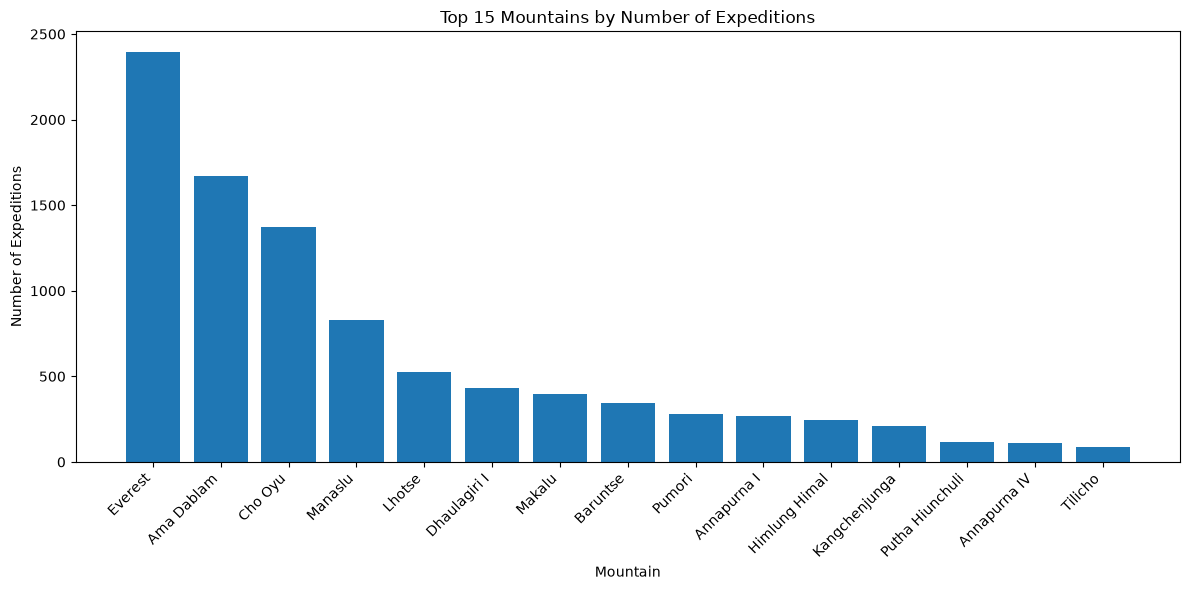

In [10]:
import matplotlib.pyplot as plt

top_exp = mountain_stats_20.sort_values(
    "EXPEDITIONS",
    ascending=False
).head(15)

plt.figure(figsize=(12, 6))

plt.bar(
    top_exp["PKNAME"],
    top_exp["EXPEDITIONS"]
)

plt.xlabel("Mountain")
plt.ylabel("Number of Expeditions")
plt.title("Top 15 Mountains by Number of Expeditions")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

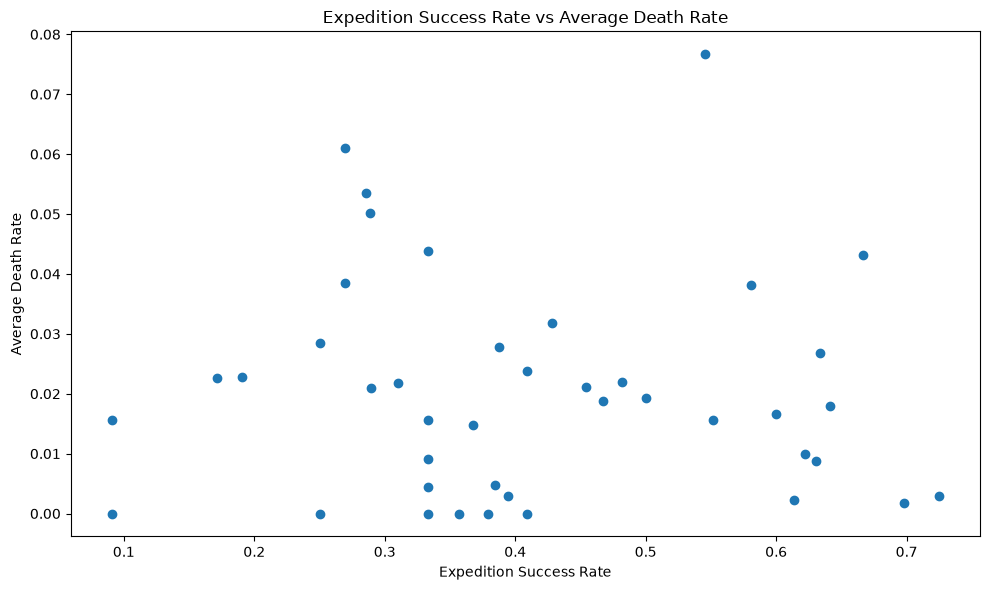

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    mountain_stats_20["SUCCESS_RATE"],
    mountain_stats_20["AVG_DEATH_RATE"]
)

plt.xlabel("Expedition Success Rate")
plt.ylabel("Average Death Rate")
plt.title("Expedition Success Rate vs Average Death Rate")

plt.tight_layout()
plt.show()

In [12]:
correlation = mountain_stats_20[
    ["SUCCESS_RATE", "AVG_DEATH_RATE"]
].corr()

print(correlation)

                SUCCESS_RATE  AVG_DEATH_RATE
SUCCESS_RATE         1.00000        -0.04768
AVG_DEATH_RATE      -0.04768         1.00000


In [13]:
mountain_stats_20 = mountain_stats_20.merge(
    peak_info[["PEAKID", "HEIGHTM"]],
    on="PEAKID",
    how="left"
)

mountain_stats_20.head()

print(
    mountain_stats_20[
        ["HEIGHTM", "SUCCESS_RATE"]
    ].corr()
)

               HEIGHTM  SUCCESS_RATE
HEIGHTM       1.000000      0.133645
SUCCESS_RATE  0.133645      1.000000


In [14]:
print(
    mountain_stats_20[
        ["HEIGHTM", "AVG_DEATH_RATE"]
    ].corr()
)

                 HEIGHTM  AVG_DEATH_RATE
HEIGHTM         1.000000        0.248104
AVG_DEATH_RATE  0.248104        1.000000


In [16]:
yearly_stats = (
    expedition_data
    .groupby("YEAR")
    .agg(
        EXPEDITIONS=("EXPID", "count"),
        SUCCESSFUL_EXPEDITIONS=("EXPEDITION_SUCCESS", "sum"),
        AVG_SUMMIT_RATE=("SUMMIT_RATE", "mean"),
        AVG_DEATH_RATE=("DEATH_RATE", "mean")
    )
    .reset_index()
)

yearly_stats["SUCCESS_RATE"] = (
    yearly_stats["SUCCESSFUL_EXPEDITIONS"]
    / yearly_stats["EXPEDITIONS"]
)

yearly_stats.head()
yearly_stats.tail()

,YEAR,EXPEDITIONS,SUCCESSFUL_EXPEDITIONS,AVG_SUMMIT_RATE,AVG_DEATH_RATE,SUCCESS_RATE
93,2021,207,124,0.390031,0.004946,0.599034
94,2022,279,188,0.416277,0.002516,0.673835
95,2023,274,219,0.514494,0.009346,0.799270
96,2024,253,196,0.489036,0.007815,0.774704
97,2025,269,205,0.487395,0.010405,0.762082


In [17]:
yearly_stats.head(10)

,YEAR,EXPEDITIONS,SUCCESSFUL_EXPEDITIONS,AVG_SUMMIT_RATE,AVG_DEATH_RATE,SUCCESS_RATE
0,1905,1,0,0.0,0.200000,0.000000
1,1907,1,0,0.0,0.000000,0.000000
2,1909,2,1,0.5,0.000000,0.500000
3,1910,3,1,0.333333,0.000000,0.333333
4,1920,3,0,0.0,0.000000,0.000000
5,1921,1,0,0.0,0.111111,0.000000
6,1922,1,0,0.0,0.000000,0.000000
7,1924,1,0,0.0,0.181818,0.000000
8,1925,2,0,0.0,0.000000,0.000000
9,1929,2,0,0.0,0.500000,0.000000


In [18]:
yearly_stats_20 = yearly_stats[
    yearly_stats["EXPEDITIONS"] >= 20
].copy()

print(
    "Years with at least 20 expeditions:",
    len(yearly_stats_20)
)

print(
    "First year with at least 20 expeditions:",
    yearly_stats_20["YEAR"].min()
)

print(
    "Last year with at least 20 expeditions:",
    yearly_stats_20["YEAR"].max()
)

Years with at least 20 expeditions: 64
First year with at least 20 expeditions: 1953
Last year with at least 20 expeditions: 2025


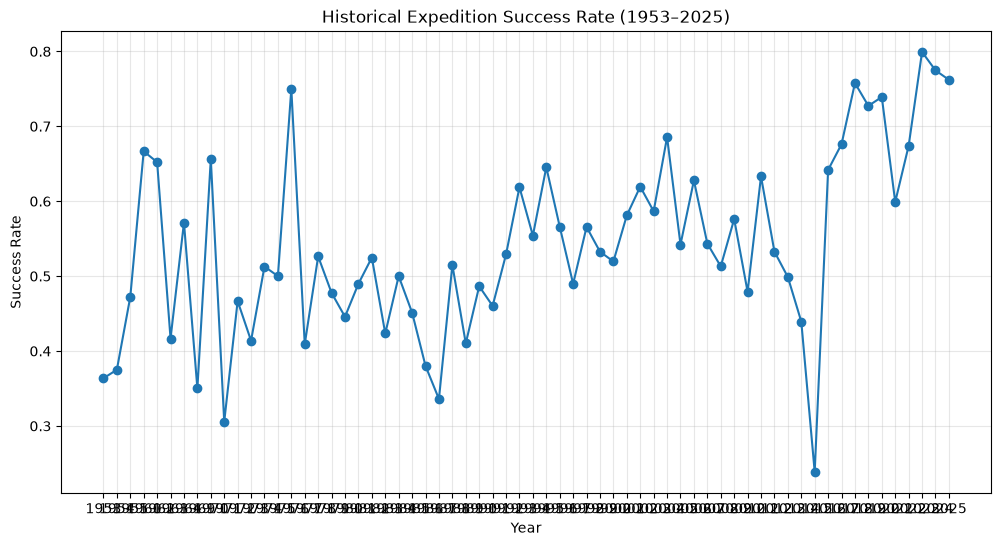

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_stats_20["YEAR"],
    yearly_stats_20["SUCCESS_RATE"],
    marker="o"
)

plt.title("Historical Expedition Success Rate (1953–2025)")
plt.xlabel("Year")
plt.ylabel("Success Rate")
plt.grid(True, alpha=0.3)

plt.show()

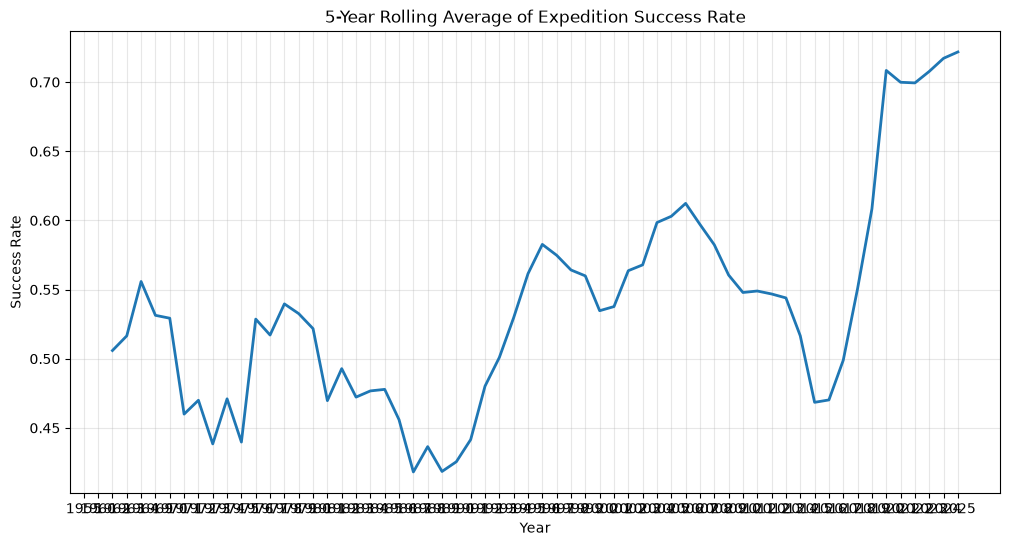

In [20]:
yearly_stats_20["SUCCESS_RATE_ROLLING"] = (
    yearly_stats_20["SUCCESS_RATE"]
    .rolling(window=5)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_stats_20["YEAR"],
    yearly_stats_20["SUCCESS_RATE_ROLLING"],
    linewidth=2
)

plt.title("5-Year Rolling Average of Expedition Success Rate")
plt.xlabel("Year")
plt.ylabel("Success Rate")
plt.grid(True, alpha=0.3)

plt.show()

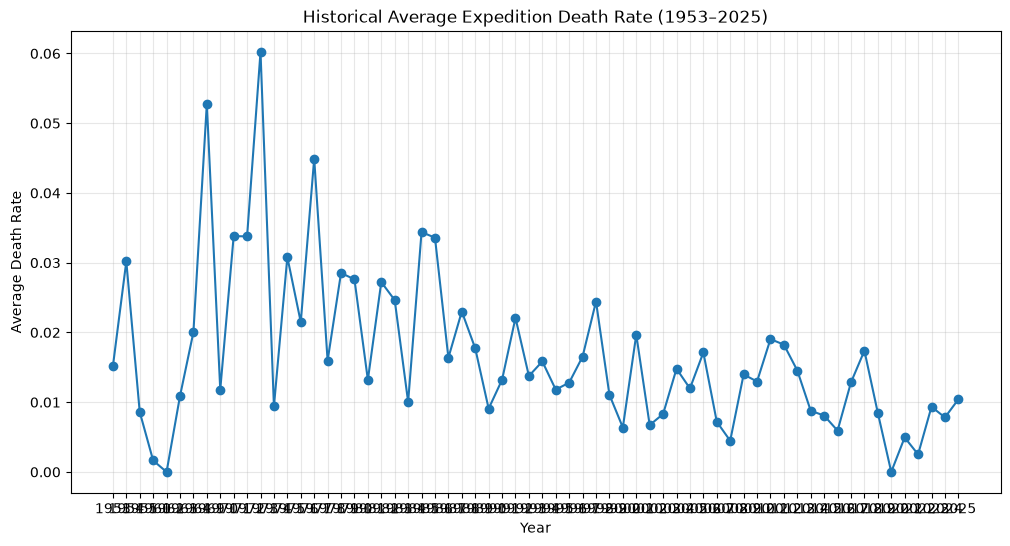

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_stats_20["YEAR"],
    yearly_stats_20["AVG_DEATH_RATE"],
    marker="o"
)

plt.title("Historical Average Expedition Death Rate (1953–2025)")
plt.xlabel("Year")
plt.ylabel("Average Death Rate")
plt.grid(True, alpha=0.3)

plt.show()

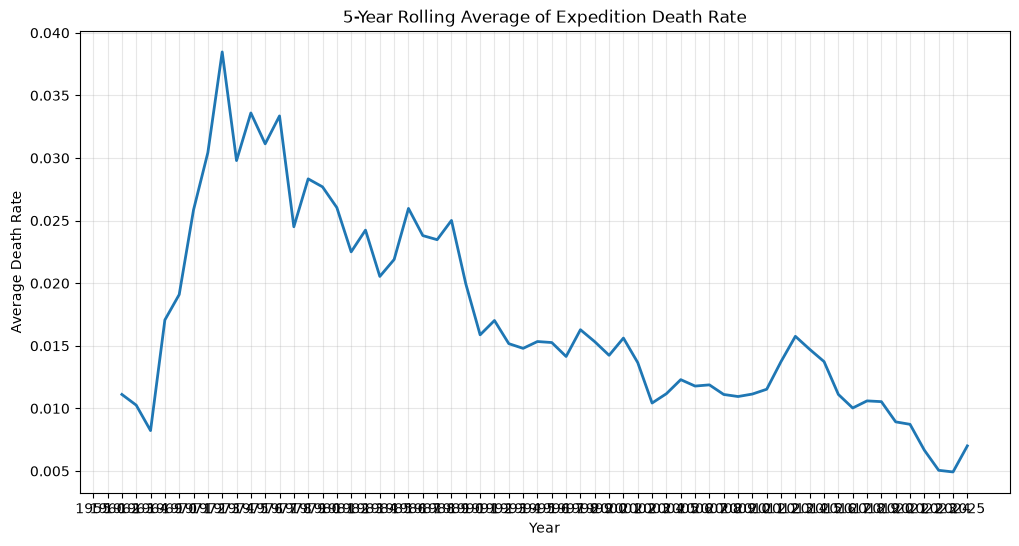

In [22]:
yearly_stats_20["DEATH_RATE_ROLLING"] = (
    yearly_stats_20["AVG_DEATH_RATE"]
    .rolling(window=5)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_stats_20["YEAR"],
    yearly_stats_20["DEATH_RATE_ROLLING"],
    linewidth=2
)

plt.title("5-Year Rolling Average of Expedition Death Rate")
plt.xlabel("Year")
plt.ylabel("Average Death Rate")
plt.grid(True, alpha=0.3)

plt.show()

In [23]:
mountain_stats_20.sort_values(
    "AVG_DEATH_RATE",
    ascending=False
)[
    [
        "PKNAME",
        "EXPEDITIONS",
        "SUCCESS_RATE",
        "AVG_SUMMIT_RATE",
        "AVG_DEATH_RATE"
    ]
].head(15)

,PKNAME,EXPEDITIONS,SUCCESS_RATE,AVG_SUMMIT_RATE,AVG_DEATH_RATE
41,Yalung Kang,22,0.545455,0.198044,0.076667
19,Himalchuli East,26,0.269231,0.110143,0.060952
9,Chamlang,28,0.285714,0.161312,0.053571
26,Langtang Lirung,52,0.288462,0.133377,0.050180
6,Api Main,21,0.333333,0.173452,0.043750
10,Cholatse,27,0.666667,0.500275,0.043210
39,Tengkangpoche,26,0.269231,0.224359,0.038462
23,Kang Guru,31,0.580645,0.324352,0.038095
12,Dhaulagiri I,432,0.428241,0.230975,0.031752
28,Lhotse Shar,36,0.250000,0.044212,0.028395


In [24]:
mountain_death_stats = (
    expedition_data
    .groupby(["PEAKID", "PKNAME"])
    .agg(
        EXPEDITIONS=("EXPID", "count"),
        TOTAL_MEMBERS=("TOTMEMBERS", "sum"),
        TOTAL_DEATHS=("MDEATHS", "sum")
    )
    .reset_index()
)

mountain_death_stats["POOLED_DEATH_RATE"] = (
    mountain_death_stats["TOTAL_DEATHS"]
    / mountain_death_stats["TOTAL_MEMBERS"].replace(0, pd.NA)
)

mountain_death_stats_20 = mountain_death_stats[
    mountain_death_stats["EXPEDITIONS"] >= 20
].copy()

mountain_death_stats_20.sort_values(
    "POOLED_DEATH_RATE",
    ascending=False
).head(15)

,PEAKID,PKNAME,EXPEDITIONS,TOTAL_MEMBERS,TOTAL_DEATHS,POOLED_DEATH_RATE
131,HIME,Himalchuli East,26,222,10,0.045045
186,KGUR,Kang Guru,31,188,8,0.042553
218,LANG,Langtang Lirung,52,323,13,0.040248
245,LSHR,Lhotse Shar,36,268,10,0.037313
253,MAK2,Makalu II,48,284,10,0.035211
7,ANN1,Annapurna I,271,1693,55,0.032487
9,ANN3,Annapurna III,38,253,8,0.031621
14,APIM,Api Main,21,131,4,0.030534
105,GANG,Gangapurna,29,172,5,0.029070
8,ANN2,Annapurna II,35,213,6,0.028169


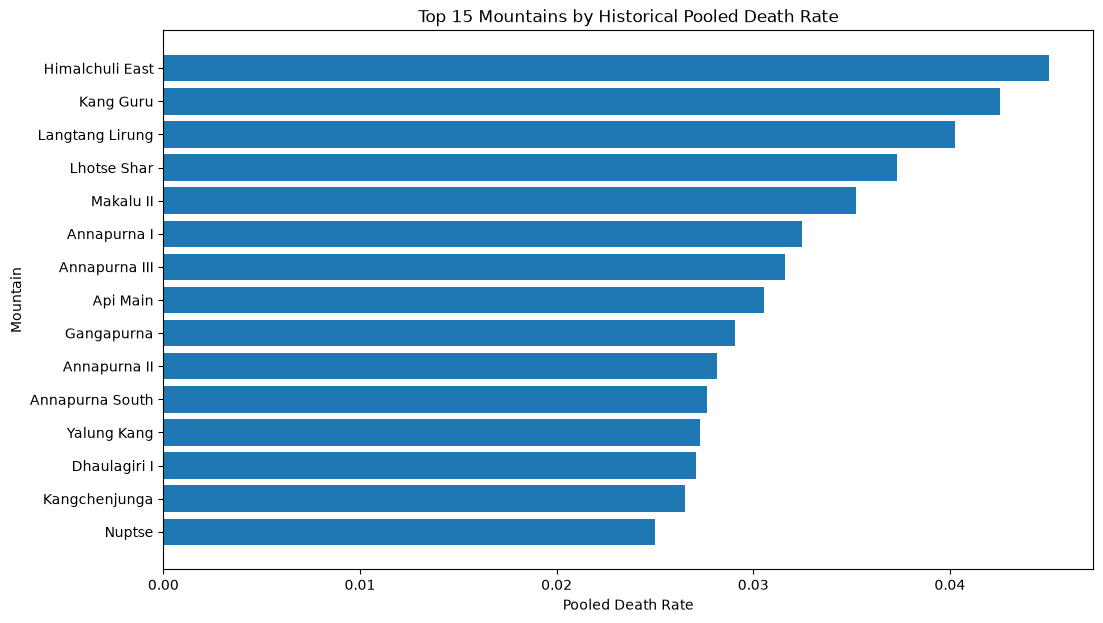

In [25]:
top_death = mountain_death_stats_20.sort_values(
    "POOLED_DEATH_RATE",
    ascending=False
).head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_death["PKNAME"],
    top_death["POOLED_DEATH_RATE"]
)

plt.xlabel("Pooled Death Rate")
plt.ylabel("Mountain")
plt.title("Top 15 Mountains by Historical Pooled Death Rate")
plt.gca().invert_yaxis()

plt.show()

In [26]:
comparison = mountain_stats_20[
    [
        "PEAKID",
        "PKNAME",
        "EXPEDITIONS",
        "SUCCESS_RATE"
    ]
].merge(
    mountain_death_stats_20[
        [
            "PEAKID",
            "POOLED_DEATH_RATE"
        ]
    ],
    on="PEAKID",
    how="inner"
)

comparison.head()

,PEAKID,PKNAME,EXPEDITIONS,SUCCESS_RATE,POOLED_DEATH_RATE
0,AMAD,Ama Dablam,1670,0.724551,0.003024
1,ANN1,Annapurna I,271,0.387454,0.032487
2,ANN2,Annapurna II,35,0.171429,0.028169
3,ANN3,Annapurna III,38,0.289474,0.031621
4,ANN4,Annapurna IV,108,0.333333,0.003807


In [27]:
correlation = comparison[
    ["SUCCESS_RATE", "POOLED_DEATH_RATE"]
].corr()

correlation

,SUCCESS_RATE,POOLED_DEATH_RATE
SUCCESS_RATE,1.000000,-0.123976
POOLED_DEATH_RATE,-0.123976,1.000000


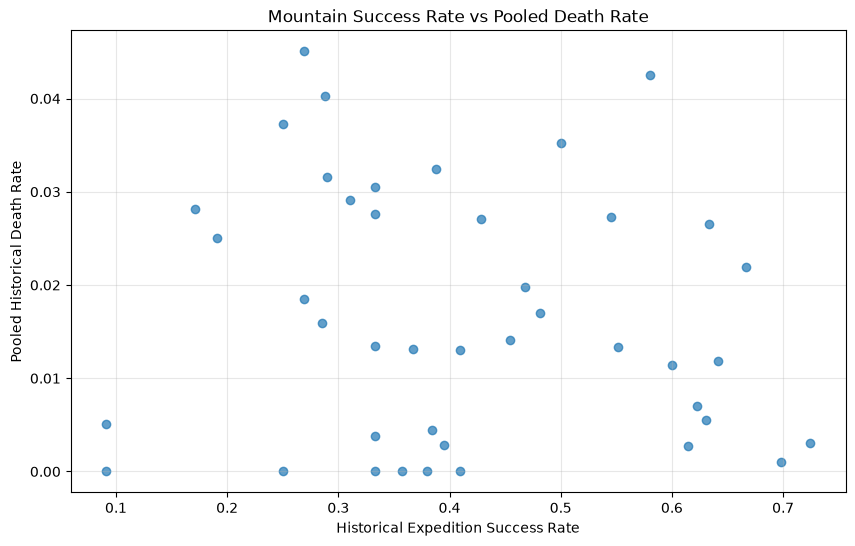

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    comparison["SUCCESS_RATE"],
    comparison["POOLED_DEATH_RATE"],
    alpha=0.7
)

plt.title("Mountain Success Rate vs Pooled Death Rate")
plt.xlabel("Historical Expedition Success Rate")
plt.ylabel("Pooled Historical Death Rate")
plt.grid(True, alpha=0.3)

plt.show()

In [29]:
height_comparison = mountain_stats_20[
    [
        "PEAKID",
        "PKNAME",
        "EXPEDITIONS",
        "SUCCESS_RATE"
    ]
].merge(
    peak_info[
        ["PEAKID", "HEIGHTM"]
    ],
    on="PEAKID",
    how="left"
).merge(
    mountain_death_stats_20[
        ["PEAKID", "POOLED_DEATH_RATE"]
    ],
    on="PEAKID",
    how="inner"
)

height_comparison[
    ["HEIGHTM", "SUCCESS_RATE", "POOLED_DEATH_RATE"]
].corr()

,HEIGHTM,SUCCESS_RATE,POOLED_DEATH_RATE
HEIGHTM,1.000000,0.133645,0.327185
SUCCESS_RATE,0.133645,1.000000,-0.123976
POOLED_DEATH_RATE,0.327185,-0.123976,1.000000


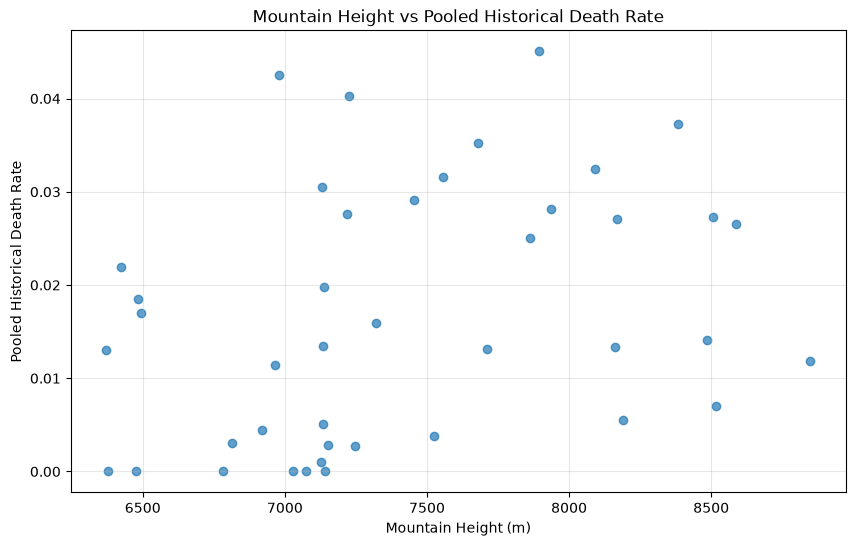

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(
    height_comparison["HEIGHTM"],
    height_comparison["POOLED_DEATH_RATE"],
    alpha=0.7
)

plt.title("Mountain Height vs Pooled Historical Death Rate")
plt.xlabel("Mountain Height (m)")
plt.ylabel("Pooled Historical Death Rate")
plt.grid(True, alpha=0.3)

plt.show()

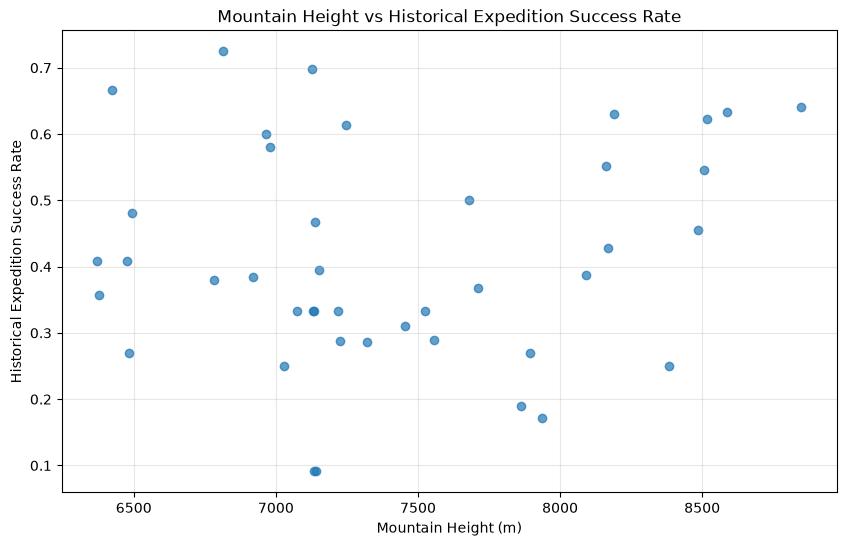

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(
    height_comparison["HEIGHTM"],
    height_comparison["SUCCESS_RATE"],
    alpha=0.7
)

plt.title("Mountain Height vs Historical Expedition Success Rate")
plt.xlabel("Mountain Height (m)")
plt.ylabel("Historical Expedition Success Rate")
plt.grid(True, alpha=0.3)

plt.show()